# Classical molecular-property baselines

This notebook compares reproducible classical baselines for the labeled HOMO–LUMO gap data. Every model input is derived exclusively from `json_conformer`; identifiers, `gap`, orbital energies, and all auxiliary quantum-mechanical properties are excluded from feature matrices.

## 1. Setup and labeled data

In [1]:
from collections import Counter
from pathlib import Path
import json
import re
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

ROOT = Path.cwd()
if not (ROOT / "datasets" / "base.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "datasets" / "base.csv").exists():
    raise FileNotFoundError("Run from the repository root or notebooks/.")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))
from loaders import mol_json_to_fingerprint

DATA_PATH = ROOT / "datasets" / "base.csv"
RESULTS_DIR = ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path.relative_to(ROOT)

df = pd.read_csv(DATA_PATH)
if "mol_id" not in df and str(df.columns[0]).startswith("Unnamed"):
    df = df.rename(columns={df.columns[0]: "mol_id"})
required = {"mol_id", "json_conformer", "gap"}
assert required.issubset(df.columns)
labeled = df.loc[df["gap"].notna(), ["mol_id", "json_conformer", "gap"]].reset_index(drop=True)
y = labeled["gap"].to_numpy(dtype=np.float64)
print(f"Using {len(labeled):,} labeled molecules; {len(df) - len(labeled):,} unlabeled rows are excluded.")
print("Input columns used:", ["json_conformer"])

Using 57,136 labeled molecules; 59,356 unlabeled rows are excluded.
Input columns used: ['json_conformer']


## 2. Feature construction

- **Size/composition:** atom, heavy-atom, bond, element, and bond-type counts.
- **RDKit 2D:** the standard RDKit descriptor registry, calculated after removing explicit hydrogens.
- **Morgan:** radius 2, 2,048 bits, using the supplied loader.
- **Simple 3D:** radius of gyration, bond-length mean/standard deviation, maximum atomic distance, and coordinate-covariance eigenvalues.

No dataframe property column other than `json_conformer` is read during feature construction.

In [2]:
ELEMENTS = ["H", "C", "N", "O", "F"]
BOND_TYPES = [1.0, 1.5, 2.0, 3.0]
size_feature_names = (
    ["n_atoms", "n_heavy_atoms", "n_bonds", "n_atom_types"]
    + [f"element_{e}" for e in ELEMENTS]
    + [f"bond_type_{b:g}" for b in BOND_TYPES]
)
geometry_feature_names = [
    "radius_of_gyration", "mean_bond_length", "std_bond_length",
    "max_atomic_distance", "coordinate_cov_eigenvalue_1",
    "coordinate_cov_eigenvalue_2", "coordinate_cov_eigenvalue_3",
]
rdkit_descriptor_names = [name for name, _ in Descriptors._descList]
rdkit_calculator = MolecularDescriptorCalculator(rdkit_descriptor_names)

def molecule_features(js):
    mol_with_h = Chem.JSONToMols(js)[0]
    atoms = [atom.GetSymbol() for atom in mol_with_h.GetAtoms()]
    atom_counts = Counter(atoms)
    bond_counts = Counter(float(bond.GetBondTypeAsDouble()) for bond in mol_with_h.GetBonds())
    size = [
        len(atoms),
        sum(symbol != "H" for symbol in atoms),
        mol_with_h.GetNumBonds(),
        len(atom_counts),
        *[atom_counts.get(e, 0) for e in ELEMENTS],
        *[bond_counts.get(b, 0) for b in BOND_TYPES],
    ]

    xyz = np.asarray(mol_with_h.GetConformer().GetPositions(), dtype=float)
    centered = xyz - xyz.mean(axis=0)
    radius = float(np.sqrt(np.mean(np.sum(centered ** 2, axis=1))))
    if len(xyz) > 1:
        distances = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
        max_distance = float(distances.max())
        eigenvalues = np.linalg.eigvalsh(centered.T @ centered / len(xyz))
    else:
        max_distance = 0.0
        eigenvalues = np.zeros(3)
    bond_lengths = np.array([
        np.linalg.norm(xyz[bond.GetBeginAtomIdx()] - xyz[bond.GetEndAtomIdx()])
        for bond in mol_with_h.GetBonds()
    ])
    geometry = [
        radius,
        float(bond_lengths.mean()) if len(bond_lengths) else np.nan,
        float(bond_lengths.std()) if len(bond_lengths) else np.nan,
        max_distance,
        *eigenvalues,
    ]

    mol_2d = Chem.RemoveHs(mol_with_h)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        descriptors_2d = rdkit_calculator.CalcDescriptors(mol_2d)
    scaffold = Chem.MolToSmiles(
        MurckoScaffold.GetScaffoldForMol(mol_2d), canonical=True
    )
    return size, geometry, descriptors_2d, scaffold

CACHE_DIR = ROOT / "outputs" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
cache_tag = f"{len(labeled)}_{int(DATA_PATH.stat().st_mtime)}"
dense_cache = CACHE_DIR / f"classical_dense_{cache_tag}.npz"
morgan_cache = CACHE_DIR / f"classical_morgan_{cache_tag}.npz"

start = time.perf_counter()
if dense_cache.exists() and morgan_cache.exists():
    cached = np.load(dense_cache)
    X_size = cached["X_size"]
    X_geometry = cached["X_geometry"]
    X_rdkit = cached["X_rdkit"]
    scaffolds = cached["scaffolds"]
    X_morgan = sparse.load_npz(morgan_cache).tocsr()
    print("Loaded deterministic json_conformer feature cache.")
else:
    records = [molecule_features(js) for js in labeled["json_conformer"]]
    X_size = np.asarray([row[0] for row in records], dtype=np.float32)
    X_geometry = np.asarray([row[1] for row in records], dtype=np.float32)
    X_rdkit = np.asarray([row[2] for row in records], dtype=np.float32)
    scaffolds = np.asarray([row[3] for row in records], dtype=str)
    del records

    X_morgan_dense = mol_json_to_fingerprint(
        labeled["json_conformer"], radius=2, n_bits=2048, n_jobs=1
    )
    X_morgan = sparse.csr_matrix(X_morgan_dense, dtype=np.float32)
    del X_morgan_dense
    np.savez_compressed(
        dense_cache,
        X_size=X_size,
        X_geometry=X_geometry,
        X_rdkit=X_rdkit,
        scaffolds=scaffolds,
    )
    sparse.save_npz(morgan_cache, X_morgan, compressed=True)
    print("Created deterministic json_conformer feature cache.")
X_combined = sparse.hstack(
    [X_morgan, sparse.csr_matrix(X_rdkit), sparse.csr_matrix(X_geometry)],
    format="csr",
    dtype=np.float32,
)
feature_seconds = time.perf_counter() - start
print(f"Feature construction: {feature_seconds:.1f} s")
print({
    "size/composition": X_size.shape,
    "RDKit 2D": X_rdkit.shape,
    "Morgan": X_morgan.shape,
    "simple 3D": X_geometry.shape,
    "combined": X_combined.shape,
    "unique_scaffolds_including_empty": len(np.unique(scaffolds)),
})

Loaded deterministic json_conformer feature cache.


Feature construction: 0.6 s
{'size/composition': (57136, 13), 'RDKit 2D': (57136, 211), 'Morgan': (57136, 2048), 'simple 3D': (57136, 7), 'combined': (57136, 2266), 'unique_scaffolds_including_empty': 20646}


## 3. Fixed splits

The random split is exactly 70/15/15. The scaffold split uses deterministic size-sorted scaffold bins and keeps each Bemis–Murcko scaffold in one subset; proportions are approximate because scaffold groups are indivisible. Empty scaffolds (acyclic molecules) are treated as one group. Test labels are not used during model selection.

In [3]:
all_idx = np.arange(len(labeled))
random_train_idx, random_temp_idx = train_test_split(
    all_idx, test_size=0.30, random_state=RANDOM_STATE
)
random_val_idx, random_test_idx = train_test_split(
    random_temp_idx, test_size=0.50, random_state=RANDOM_STATE
)

scaffold_groups = {}
for idx, scaffold in enumerate(scaffolds):
    scaffold_groups.setdefault(scaffold, []).append(idx)
ordered_groups = sorted(
    scaffold_groups.items(),
    key=lambda item: (-len(item[1]), item[0]),
)
train_cutoff = int(0.70 * len(labeled))
validation_cutoff = int(0.85 * len(labeled))
scaffold_train, scaffold_validation, scaffold_test = [], [], []
for _, group_indices in ordered_groups:
    if len(scaffold_train) + len(group_indices) <= train_cutoff:
        scaffold_train.extend(group_indices)
    elif (
        len(scaffold_train) + len(scaffold_validation) + len(group_indices)
        <= validation_cutoff
    ):
        scaffold_validation.extend(group_indices)
    else:
        scaffold_test.extend(group_indices)
scaffold_train_idx = np.asarray(scaffold_train, dtype=int)
scaffold_val_idx = np.asarray(scaffold_validation, dtype=int)
scaffold_test_idx = np.asarray(scaffold_test, dtype=int)

splits = {
    "random": (random_train_idx, random_val_idx, random_test_idx),
    "scaffold": (scaffold_train_idx, scaffold_val_idx, scaffold_test_idx),
}

split_summary = []
for strategy, (train_idx, val_idx, test_idx) in splits.items():
    split_summary.append({
        "strategy": strategy,
        "train": len(train_idx),
        "validation": len(val_idx),
        "test": len(test_idx),
        "train_pct": 100 * len(train_idx) / len(labeled),
        "validation_pct": 100 * len(val_idx) / len(labeled),
        "test_pct": 100 * len(test_idx) / len(labeled),
        "train_validation_scaffold_overlap": len(
            set(scaffolds[train_idx]) & set(scaffolds[val_idx])
        ) if strategy == "scaffold" else np.nan,
        "train_test_scaffold_overlap": len(
            set(scaffolds[train_idx]) & set(scaffolds[test_idx])
        ) if strategy == "scaffold" else np.nan,
    })
display(pd.DataFrame(split_summary).set_index("strategy"))

,train,validation,test,train_pct,validation_pct,test_pct,train_validation_scaffold_overlap,train_test_scaffold_overlap
strategy,,,,,,,,
random,39995,8570,8571,69.99965,14.9993,15.00105,NaN,NaN
scaffold,39995,8570,8571,69.99965,14.9993,15.00105,0.0,0.0


## 4. Pipelines and limited validation tuning

Ridge searches only `α ∈ {0.1, 1, 10}`. Boosting compares two small tree configurations with 30 estimators. All imputers and scalers are fitted inside pipelines on the training subset only. Validation MAE selects one configuration per model; the random test set remains untouched in this section.

In [4]:
try:
    from lightgbm import LGBMRegressor
    BOOSTER_NAME = "LightGBM"
except ImportError:
    LGBMRegressor = None
    BOOSTER_NAME = "HistGradientBoostingRegressor"
print("Boosting backend:", BOOSTER_NAME)

def to_dense(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)

def make_booster(params):
    if LGBMRegressor is not None:
        return LGBMRegressor(
            objective="regression_l1",
            n_estimators=30,
            learning_rate=0.1,
            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],
            subsample=0.9,
            colsample_bytree=0.5,
            max_bin=63,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=params["num_leaves"],
        min_samples_leaf=params["min_child_samples"],
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )

ridge_candidates = [{"alpha": value} for value in [0.1, 1.0, 10.0]]
boost_candidates = [
    {"num_leaves": 31, "min_child_samples": 20},
    {"num_leaves": 63, "min_child_samples": 30},
]

MODEL_SPECS = {
    "Mean predictor": ("mean", None, [{}]),
    "Size/composition + Ridge": ("dense_ridge", X_size, ridge_candidates),
    "RDKit 2D + Ridge": ("dense_ridge", X_rdkit, ridge_candidates),
    f"RDKit 2D + {BOOSTER_NAME}": ("dense_boost", X_rdkit, boost_candidates),
    "Morgan + Ridge": ("sparse_ridge", X_morgan, ridge_candidates),
    f"Morgan + {BOOSTER_NAME}": ("sparse_boost", X_morgan, boost_candidates),
    f"Morgan + RDKit 2D + simple 3D + {BOOSTER_NAME}":
        ("combined_boost", X_combined, boost_candidates),
}

def build_pipeline(kind, params):
    if kind == "mean":
        return Pipeline([("regressor", DummyRegressor(strategy="mean"))])
    if kind == "dense_ridge":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("regressor", Ridge(alpha=params["alpha"], solver="lsqr")),
        ])
    if kind == "sparse_ridge":
        return Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("regressor", Ridge(alpha=params["alpha"], solver="lsqr")),
        ])
    if kind == "dense_boost":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("regressor", make_booster(params)),
        ])
    if kind == "sparse_boost":
        steps = []
        if LGBMRegressor is None:
            steps.append(("densify", FunctionTransformer(to_dense, accept_sparse=True)))
        steps.append(("regressor", make_booster(params)))
        return Pipeline(steps)
    if kind == "combined_boost":
        n_fp = X_morgan.shape[1]
        preprocess = ColumnTransformer([
            ("fingerprint", "passthrough", slice(0, n_fp)),
            ("descriptors", SimpleImputer(strategy="median"), slice(n_fp, X_combined.shape[1])),
        ], sparse_threshold=1.0)
        steps = [("preprocess", preprocess)]
        if LGBMRegressor is None:
            steps.append(("densify", FunctionTransformer(to_dense, accept_sparse=True)))
        steps.append(("regressor", make_booster(params)))
        return Pipeline(steps)
    raise ValueError(kind)

def matrix_rows(matrix, indices):
    if matrix is None:
        return np.zeros((len(indices), 1), dtype=np.float32)
    return matrix[indices]

train_idx, val_idx, _ = splits["random"]
selected_models = {}
selection_rows = []
descriptor_model_names = {
    "Size/composition + Ridge",
    "RDKit 2D + Ridge",
    f"RDKit 2D + {BOOSTER_NAME}",
}

for model_name, (kind, matrix, candidates) in MODEL_SPECS.items():
    candidate_rows = []
    total_fit_seconds = 0.0
    best = None
    for params in candidates:
        pipeline = build_pipeline(kind, params)
        started = time.perf_counter()
        pipeline.fit(matrix_rows(matrix, train_idx), y[train_idx])
        fit_seconds = time.perf_counter() - started
        total_fit_seconds += fit_seconds
        validation_prediction = pipeline.predict(matrix_rows(matrix, val_idx))
        validation_mae = mean_absolute_error(y[val_idx], validation_prediction)
        candidate_rows.append({
            "model": model_name,
            "parameters": json.dumps(params, sort_keys=True),
            "validation_mae": validation_mae,
            "fit_seconds": fit_seconds,
        })
        if best is None or validation_mae < best["validation_mae"]:
            best = {
                "pipeline": pipeline,
                "parameters": params,
                "validation_mae": validation_mae,
                "validation_prediction": validation_prediction,
            }
    best["total_tuning_fit_seconds"] = total_fit_seconds
    best["kind"] = kind
    best["matrix"] = matrix
    selected_models[model_name] = best
    selection_rows.extend(candidate_rows)

selection_table = pd.DataFrame(selection_rows)
display(selection_table.sort_values(["model", "validation_mae"]))
display(pd.DataFrame([
    {
        "model": name,
        "selected_parameters": json.dumps(info["parameters"], sort_keys=True),
        "validation_mae": info["validation_mae"],
        "training_and_tuning_seconds": info["total_tuning_fit_seconds"],
    }
    for name, info in selected_models.items()
]).sort_values("validation_mae"))

Boosting backend: LightGBM


,model,parameters,validation_mae,fit_seconds
0,Mean predictor,{},0.043148,0.001711
13,Morgan + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.017712,72.307120
12,Morgan + LightGBM,"{""min_child_samples"": 20, ""num_leaves"": 31}",0.019175,52.368792
15,Morgan + RDKit 2D + simple 3D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.013886,68.218885
14,Morgan + RDKit 2D + simple 3D + LightGBM,"{""min_child_samples"": 20, ""num_leaves"": 31}",0.014920,38.026485
11,Morgan + Ridge,"{""alpha"": 10.0}",0.054756,0.103049
10,Morgan + Ridge,"{""alpha"": 1.0}",0.054779,0.102714
9,Morgan + Ridge,"{""alpha"": 0.1}",0.054782,0.105369
8,RDKit 2D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.014132,37.617555
7,RDKit 2D + LightGBM,"{""min_child_samples"": 20, ""num_leaves"": 31}",0.015211,31.476221


,model,selected_parameters,validation_mae,training_and_tuning_seconds
6,Morgan + RDKit 2D + simple 3D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.013886,106.245370
3,RDKit 2D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.014132,69.093776
5,Morgan + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.017712,124.675912
2,RDKit 2D + Ridge,"{""alpha"": 10.0}",0.023180,5.384907
1,Size/composition + Ridge,"{""alpha"": 0.1}",0.024816,0.442234
0,Mean predictor,{},0.043148,0.001711
4,Morgan + Ridge,"{""alpha"": 10.0}",0.054756,0.311132


## 5. Final random-split evaluation

Only after every configuration has been selected using validation MAE do we score the held-out random test set. Models remain fitted on the 70% training subset, so test information never affects preprocessing, tuning, or fitting.

In [5]:
_, _, test_idx = splits["random"]
random_result_rows = []
random_predictions = {}

for model_name, info in selected_models.items():
    test_prediction = info["pipeline"].predict(matrix_rows(info["matrix"], test_idx))
    random_predictions[model_name] = test_prediction
    random_result_rows.append({
        "split_strategy": "random",
        "model": model_name,
        "selected_parameters": json.dumps(info["parameters"], sort_keys=True),
        "validation_mae": info["validation_mae"],
        "test_mae": mean_absolute_error(y[test_idx], test_prediction),
        "test_rmse": mean_squared_error(y[test_idx], test_prediction) ** 0.5,
        "test_r2": r2_score(y[test_idx], test_prediction),
        "training_time_seconds": info["total_tuning_fit_seconds"],
        "train_samples": len(splits["random"][0]),
        "validation_samples": len(splits["random"][1]),
        "test_samples": len(test_idx),
    })

random_results = pd.DataFrame(random_result_rows).sort_values("validation_mae")
display(random_results)
best_model_names = random_results.head(3)["model"].tolist()
print("Selected for scaffold robustness:", best_model_names)

,split_strategy,model,selected_parameters,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,train_samples,validation_samples,test_samples
6,random,Morgan + RDKit 2D + simple 3D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.013886,0.014261,0.367294,0.017775,106.245370,39995,8570,8571
3,random,RDKit 2D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.014132,0.014442,0.367354,0.017457,69.093776,39995,8570,8571
5,random,Morgan + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.017712,0.017992,0.367537,0.016474,124.675912,39995,8570,8571
2,random,RDKit 2D + Ridge,"{""alpha"": 10.0}",0.023180,0.023821,0.367800,0.015071,5.384907,39995,8570,8571
1,random,Size/composition + Ridge,"{""alpha"": 0.1}",0.024816,0.025449,0.368175,0.013059,0.442234,39995,8570,8571
0,random,Mean predictor,{},0.043148,0.043398,0.370603,-0.000002,0.001711,39995,8570,8571
4,random,Morgan + Ridge,"{""alpha"": 10.0}",0.054756,0.055864,0.375028,-0.024023,0.311132,39995,8570,8571


Selected for scaffold robustness: ['Morgan + RDKit 2D + simple 3D + LightGBM', 'RDKit 2D + LightGBM', 'Morgan + LightGBM']


## 6. Scaffold robustness for the top three models

The three model families selected by random-validation MAE are refitted on scaffold-training data using their already-selected hyperparameters. Scaffold validation is reported diagnostically and is not used for further tuning.

In [6]:
scaffold_train_idx, scaffold_val_idx, scaffold_test_idx = splits["scaffold"]
scaffold_rows = []
scaffold_predictions = {}

for model_name in best_model_names:
    selected = selected_models[model_name]
    pipeline = build_pipeline(selected["kind"], selected["parameters"])
    started = time.perf_counter()
    pipeline.fit(matrix_rows(selected["matrix"], scaffold_train_idx), y[scaffold_train_idx])
    fit_seconds = time.perf_counter() - started
    val_prediction = pipeline.predict(matrix_rows(selected["matrix"], scaffold_val_idx))
    test_prediction = pipeline.predict(matrix_rows(selected["matrix"], scaffold_test_idx))
    scaffold_predictions[model_name] = test_prediction
    scaffold_rows.append({
        "split_strategy": "scaffold",
        "model": model_name,
        "selected_parameters": json.dumps(selected["parameters"], sort_keys=True),
        "validation_mae": mean_absolute_error(y[scaffold_val_idx], val_prediction),
        "test_mae": mean_absolute_error(y[scaffold_test_idx], test_prediction),
        "test_rmse": mean_squared_error(y[scaffold_test_idx], test_prediction) ** 0.5,
        "test_r2": r2_score(y[scaffold_test_idx], test_prediction),
        "training_time_seconds": fit_seconds,
        "train_samples": len(scaffold_train_idx),
        "validation_samples": len(scaffold_val_idx),
        "test_samples": len(scaffold_test_idx),
    })

scaffold_results = pd.DataFrame(scaffold_rows).sort_values("validation_mae")
all_results = pd.concat([random_results, scaffold_results], ignore_index=True)
all_results.to_csv(RESULTS_DIR / "classical_baselines.csv", index=False)
display(scaffold_results)
print("Saved:", (RESULTS_DIR / "classical_baselines.csv").relative_to(ROOT))

,split_strategy,model,selected_parameters,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,train_samples,validation_samples,test_samples
1,scaffold,RDKit 2D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.014571,0.021636,0.515264,0.010571,40.396960,39995,8570,8571
0,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.014583,0.021821,0.515300,0.010435,66.518367,39995,8570,8571
2,scaffold,Morgan + LightGBM,"{""min_child_samples"": 30, ""num_leaves"": 63}",0.017600,0.026001,0.515610,0.009242,48.172072,39995,8570,8571


Saved: results/classical_baselines.csv


## 7. Diagnostics for the best random-validation model

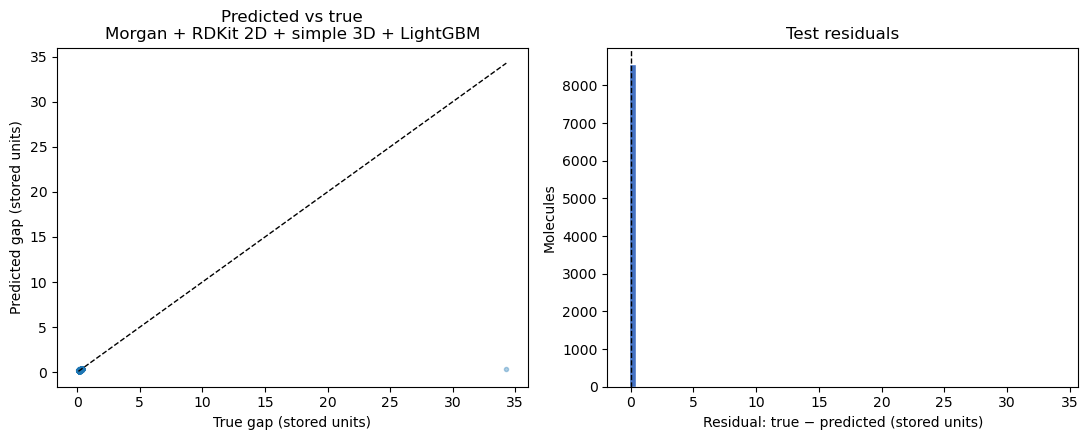

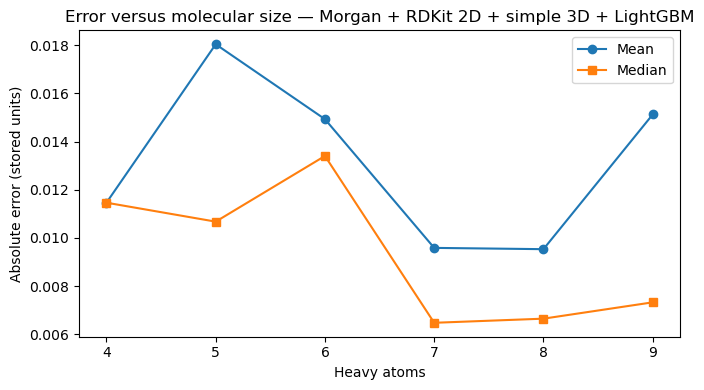

,mol_id,true_gap,predicted_gap,residual,absolute_error,n_heavy_atoms,scaffold
0,79512,34.2900,0.313908,33.976092,33.976092,9,[C@H2]1C2[C@H2]C1[C@@]21[C@H2]O1
1,23280,0.1738,0.324288,-0.150488,0.150488,8,C1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1[C@H]23
2,69005,0.1694,0.312986,-0.143586,0.143586,9,C1[C@H2][C@H]2C3[C@H]2[C@H2][C@H]13
3,111279,0.0938,0.193206,-0.099406,0.099406,9,c1ncon1
4,3971,0.2021,0.300485,-0.098385,0.098385,9,C1[C@H2][C@@H]2[C@@H2][N@@H+]3[C@H2][C@H]1[C@H]23
5,115101,0.1132,0.211243,-0.098043,0.098043,9,c1ccoc1
6,101964,0.1436,0.238698,-0.095098,0.095098,9,O=C1C[C@H]2[C@H2][C@@H]3[C@H]2N13
7,591,0.1852,0.272285,-0.087085,0.087085,9,[C@@H2]1[C@@H2][C@H]2NNN3[C@H2][C@@H]1[C@@H]23
8,95176,0.1521,0.238753,-0.086653,0.086653,8,[C@H2]1[NH2+][C@@H]2O[C@H]3C2[C@@H]13
9,3852,0.2140,0.299801,-0.085801,0.085801,9,C1C[C@H2]1


In [ ]:
best_model_name = random_results.iloc[0]["model"]
best_prediction = random_predictions[best_model_name]
best_true = y[test_idx]
best_residual = best_true - best_prediction
best_abs_error = np.abs(best_residual)
test_heavy_atoms = X_size[test_idx, size_feature_names.index("n_heavy_atoms")]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(best_true, best_prediction, s=9, alpha=0.35)
limits = [
    min(best_true.min(), best_prediction.min()),
    max(best_true.max(), best_prediction.max()),
]
axes[0].plot(limits, limits, "--", color="black", linewidth=1)
axes[0].set(
    xlabel="True gap (stored units)",
    ylabel="Predicted gap (stored units)",
    title=f"Predicted vs true\n{best_model_name}",
    xscale="log",
    yscale="log"
)
axes[1].hist(best_residual, bins=60, color="#4472C4", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="Residual: true − predicted (stored units)",
    ylabel="Molecules",
    title="Test residuals",
)
savefig("best_model_predictions_and_residuals")

size_error = (
    pd.DataFrame({"n_heavy_atoms": test_heavy_atoms.astype(int), "absolute_error": best_abs_error})
    .groupby("n_heavy_atoms")["absolute_error"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
plt.figure(figsize=(7, 4))
plt.plot(size_error["n_heavy_atoms"], size_error["mean"], marker="o", label="Mean")
plt.plot(size_error["n_heavy_atoms"], size_error["median"], marker="s", label="Median")
plt.xlabel("Heavy atoms")
plt.ylabel("Absolute error (stored units)")
plt.title(f"Error versus molecular size — {best_model_name}")
plt.legend()
savefig("best_model_error_vs_size")

worst_order = np.argsort(best_abs_error)[-20:][::-1]
worst_predictions = pd.DataFrame({
    "mol_id": labeled.iloc[test_idx[worst_order]]["mol_id"].to_numpy(),
    "true_gap": best_true[worst_order],
    "predicted_gap": best_prediction[worst_order],
    "residual": best_residual[worst_order],
    "absolute_error": best_abs_error[worst_order],
    "n_heavy_atoms": test_heavy_atoms[worst_order].astype(int),
    "scaffold": scaffolds[test_idx[worst_order]],
})
worst_predictions.to_csv(RESULTS_DIR / "worst_predicted_molecules.csv", index=False)
display(worst_predictions)

## 8. Feature importance for the best descriptor-only model

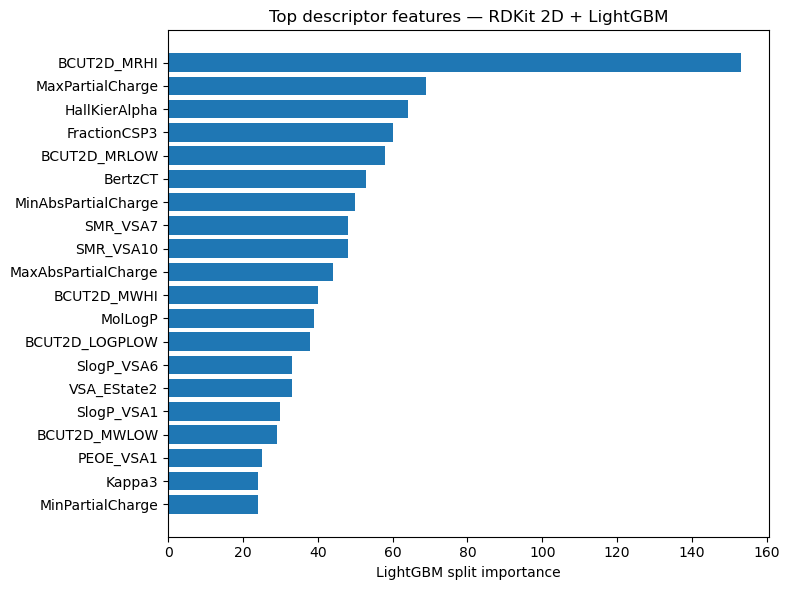

,feature,importance
24,BCUT2D_MRHI,153
11,MaxPartialCharge,69
41,HallKierAlpha,64
105,FractionCSP3,60
25,BCUT2D_MRLOW,58
28,BertzCT,53
14,MinAbsPartialCharge,50
62,SMR_VSA10,48
68,SMR_VSA7,48
13,MaxAbsPartialCharge,44


In [8]:
descriptor_rank = random_results[
    random_results["model"].isin(descriptor_model_names)
].sort_values("validation_mae")
best_descriptor_name = descriptor_rank.iloc[0]["model"]
descriptor_info = selected_models[best_descriptor_name]
descriptor_pipeline = descriptor_info["pipeline"]

if best_descriptor_name == "Size/composition + Ridge":
    importance_names = size_feature_names
    importance_values = np.abs(descriptor_pipeline.named_steps["regressor"].coef_)
    importance_label = "|standardized Ridge coefficient|"
elif best_descriptor_name == "RDKit 2D + Ridge":
    importance_names = rdkit_descriptor_names
    importance_values = np.abs(descriptor_pipeline.named_steps["regressor"].coef_)
    importance_label = "|standardized Ridge coefficient|"
else:
    importance_names = rdkit_descriptor_names
    importance_values = descriptor_pipeline.named_steps["regressor"].feature_importances_
    importance_label = "LightGBM split importance"

feature_importance = (
    pd.DataFrame({"feature": importance_names, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(20)
    .sort_values("importance")
)
plt.figure(figsize=(8, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel(importance_label)
plt.title(f"Top descriptor features — {best_descriptor_name}")
savefig("best_descriptor_feature_importance")
display(feature_importance.sort_values("importance", ascending=False))

## 9. Discussion

In [9]:
random_by_model = random_results.set_index("model")
mean_mae = random_by_model.loc["Mean predictor", "validation_mae"]
size_mae = random_by_model.loc["Size/composition + Ridge", "validation_mae"]
best_descriptor_mae = descriptor_rank.iloc[0]["validation_mae"]
fingerprint_names = ["Morgan + Ridge", f"Morgan + {BOOSTER_NAME}"]
best_fingerprint_row = random_results[random_results["model"].isin(fingerprint_names)].iloc[0]
combined_name = f"Morgan + RDKit 2D + simple 3D + {BOOSTER_NAME}"
combined_mae = random_by_model.loc[combined_name, "validation_mae"]
morgan_boost_mae = random_by_model.loc[f"Morgan + {BOOSTER_NAME}", "validation_mae"]
geometry_gain = morgan_boost_mae - combined_mae

scaffold_comparison = scaffold_results.set_index("model")["test_mae"]
random_comparison = random_results.set_index("model")["test_mae"]
common_models = scaffold_comparison.index.intersection(random_comparison.index)
mean_scaffold_penalty = (
    scaffold_comparison.loc[common_models] - random_comparison.loc[common_models]
).mean()

geometry_recommendation = (
    "A geometry-aware GNN is justified as the next controlled experiment because the combined "
    "2D/3D model improved validation MAE; it should still be compared against the strong classical baseline."
    if geometry_gain > 0
    else
    "Simple 3D features did not improve validation MAE over Morgan boosting, so a geometry-aware GNN "
    "is not yet justified by these baselines alone; first strengthen and validate the 2D baseline."
)

display(Markdown(f'''
### Classical-baseline interpretation

- **Molecular size:** size/composition Ridge changes validation MAE from {mean_mae:.4f} for the mean baseline to {size_mae:.4f}, quantifying the signal available from simple composition alone.
- **Descriptors versus fingerprints:** the best descriptor-only validation MAE is {best_descriptor_mae:.4f}; the best Morgan model reaches {best_fingerprint_row["validation_mae"]:.4f}. This compares global physicochemical summaries with hashed local substructures under the same split.
- **Simple 3D contribution:** adding RDKit and simple geometric descriptors to Morgan boosting changes validation MAE by {geometry_gain:+.4f} in the favorable direction (positive means improvement).
- **Random versus scaffold:** across the top models, scaffold test MAE is on average {mean_scaffold_penalty:+.4f} relative to random test MAE. This is the more realistic robustness check for unseen molecular cores.
- **Next step:** {geometry_recommendation}

The extreme target values identified in EDA were retained. MAE remains the primary selection metric because RMSE and R² are especially sensitive to those few observations. No test score influenced model selection.
'''))


### Classical-baseline interpretation

- **Molecular size:** size/composition Ridge changes validation MAE from 0.0431 for the mean baseline to 0.0248, quantifying the signal available from simple composition alone.
- **Descriptors versus fingerprints:** the best descriptor-only validation MAE is 0.0141; the best Morgan model reaches 0.0177. This compares global physicochemical summaries with hashed local substructures under the same split.
- **Simple 3D contribution:** adding RDKit and simple geometric descriptors to Morgan boosting changes validation MAE by +0.0038 in the favorable direction (positive means improvement).
- **Random versus scaffold:** across the top models, scaffold test MAE is on average +0.0076 relative to random test MAE. This is the more realistic robustness check for unseen molecular cores.
- **Next step:** A geometry-aware GNN is justified as the next controlled experiment because the combined 2D/3D model improved validation MAE; it should still be compared against the strong classical baseline.

The extreme target values identified in EDA were retained. MAE remains the primary selection metric because RMSE and R² are especially sensitive to those few observations. No test score influenced model selection.
